# 04 - Mô hình dự báo doanh thu

Notebook này xây dựng mô hình dự báo doanh thu từ data 2023-2025, dự báo T1-T5/2026 và so sánh với thực tế 2026.

In [1]:
import site
import sys
from pathlib import Path

USER_SITE = site.getusersitepackages()
if Path(USER_SITE).exists() and USER_SITE not in sys.path:
    sys.path.insert(0, USER_SITE)

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

import importlib
import src.pipeline as pipeline
import src.modeling as modeling
import src.config as config

importlib.reload(modeling)
importlib.reload(pipeline)
importlib.reload(config)

load_final_sales = pipeline.load_final_sales
run_modeling_stage = pipeline.run_modeling_stage
MART_DIR = config.MART_DIR
MODEL_DATA_DIR = config.MODEL_DATA_DIR

final_sales = load_final_sales()
model_result = run_modeling_stage(final_sales)
monthly_base = model_result["monthly_model_base"]
monthly_model = model_result["monthly_model_data"]
forecast = model_result["forecast_revenue_2026"]
comparison = model_result["forecast_vs_actual"]
artifacts = model_result["model_artifacts"]

# Kiểm tra nhanh dữ liệu thực tế 2026 trước khi so sánh
actual_check = final_sales[(final_sales["Năm"] == 2026) & (final_sales["Tháng"].between(1, 5))] \
    .groupby(["Năm", "Tháng"], as_index=False)["Doanh thu thuần"].sum()
print("Doanh thu thực tế T1-T5/2026 từ sales_final:")
display(actual_check)

Doanh thu thực tế T1-T5/2026 từ sales_final:


,Năm,Tháng,Doanh thu thuần
0,2026,1,"2,687,771,826.61"
1,2026,2,"1,751,996,098.16"
2,2026,3,"3,752,727,791.53"
3,2026,4,"5,762,781,848.29"
4,2026,5,"6,240,039,186.79"


In [2]:
print("Monthly base:", monthly_base.shape)
print("Monthly model:", monthly_model.shape)
display(monthly_base.head())
display(monthly_model.head())

Monthly base: (36, 19)
Monthly model: (24, 19)


,Năm,Tháng,Quý,Doanh thu thuần,Doanh số,Chiết khấu,Số lượng,Khối lượng KG,Số đơn hàng,Số khách hàng,Số sản phẩm,Chỉ số thời gian,Tỷ lệ chiết khấu,Giá trị TB/đơn,Tháng_sin,Tháng_cos,Doanh thu trễ 1 tháng,Doanh thu trễ 12 tháng,Doanh thu TB 3 tháng trước
0,2023,1,1,"3,560,249,002.00","3,502,288,680.00","391,878.00","55,645.00","24,194.50",584,88,60,1,0.00,"6,096,316.78",0.50,0.87,NaN,NaN,NaN
1,2023,2,1,"2,632,680,444.00","2,634,061,460.00","1,381,016.00","27,721.00","15,935.97",477,84,52,2,0.00,"5,519,246.21",0.87,0.50,"3,560,249,002.00",NaN,NaN
2,2023,3,1,"3,159,237,356.00","3,159,574,990.00","337,634.00","77,371.50","27,204.01",607,86,57,3,0.00,"5,204,674.39",1.00,0.00,"2,632,680,444.00",NaN,NaN
3,2023,4,2,"1,673,823,152.00","1,674,473,670.00","650,518.00","41,676.00","7,883.44",472,82,59,4,0.00,"3,546,235.49",0.87,-0.50,"3,159,237,356.00",NaN,"3,117,388,934.00"
4,2023,5,2,"2,114,582,932.00","2,115,679,970.00","1,097,038.00","43,456.00","20,714.27",490,80,56,5,0.00,"4,315,475.37",0.50,-0.87,"1,673,823,152.00",NaN,"2,488,580,317.33"


,Năm,Tháng,Quý,Doanh thu thuần,Doanh số,Chiết khấu,Số lượng,Khối lượng KG,Số đơn hàng,Số khách hàng,Số sản phẩm,Chỉ số thời gian,Tỷ lệ chiết khấu,Giá trị TB/đơn,Tháng_sin,Tháng_cos,Doanh thu trễ 1 tháng,Doanh thu trễ 12 tháng,Doanh thu TB 3 tháng trước
0,2024,1,1,"4,285,599,056.00","4,286,460,820.00","861,764.00","57,391.50","35,650.99",600,99,68,13,0.00,"7,142,665.09",0.50,0.87,"4,177,675,874.29","3,560,249,002.00","4,113,246,761.33"
1,2024,2,1,"2,299,951,796.00","2,300,084,950.00","133,154.00","508,675.00","18,889.51",436,75,56,14,0.00,"5,275,118.80",0.87,0.50,"4,285,599,056.00","2,632,680,444.00","4,896,810,070.68"
2,2024,3,1,"4,351,010,965.00","4,351,379,810.00","368,845.00","97,279.50","37,713.96",594,98,59,15,0.00,"7,324,934.28",1.00,0.00,"2,299,951,796.00","3,159,237,356.00","3,587,742,242.10"
3,2024,4,2,"4,780,635,834.00","4,781,969,380.00","1,333,546.00","51,289.50","23,839.17",464,83,57,16,0.00,"10,303,094.47",0.87,-0.50,"4,351,010,965.00","1,673,823,152.00","3,645,520,605.67"
4,2024,5,2,"4,347,643,814.00","4,348,045,580.00","401,766.00","50,544.50","37,910.07",537,85,59,17,0.00,"8,096,170.98",0.50,-0.87,"4,780,635,834.00","2,114,582,932.00","3,810,532,865.00"


In [3]:
print("Đánh giá mô hình doanh thu")
display(artifacts["model_revenue_metrics"])
print("Backtest T1-T5/2025")
display(artifacts["backtest_revenue"])

Đánh giá mô hình doanh thu


,Mô hình,MAE,MAPE,R2
0,Ridge,"304,208,075.86",0.15,0.92
1,XGBoost,"621,451,390.93",0.21,0.75
2,Gradient Boosting,"708,484,076.93",0.26,0.68
3,Random Forest,"663,962,941.91",0.29,0.75


Backtest T1-T5/2025


,Năm,Tháng,Doanh thu thuần,Doanh thu dự báo,Chênh lệch,Tỷ lệ chênh lệch
12,2025,1,"4,028,914,626.89","4,842,975,548.01","-814,060,921.12",-0.17
13,2025,2,"3,379,480,777.26","3,346,196,948.36","33,283,828.90",0.01
14,2025,3,"5,158,944,365.15","5,073,346,654.48","85,597,710.67",0.02
15,2025,4,"1,017,793,656.30","1,466,662,475.53","-448,868,819.23",-0.31
16,2025,5,"2,086,779,507.85","2,226,008,607.22","-139,229,099.36",-0.06


Dự báo doanh thu T1-T5/2026


,Năm,Tháng,Doanh thu dự báo
0,2026,1,"4,238,526,594.46"
1,2026,2,"3,532,334,069.16"
2,2026,3,"5,183,290,374.41"
3,2026,4,"935,155,607.42"
4,2026,5,"2,008,224,357.40"


So sánh dự báo với thực tế 2026


,Năm,Tháng,Doanh thu dự báo,Doanh thu thực tế,Lợi nhuận thực tế,Tổng giá vốn,Doanh số thực tế,Chiết khấu,Giá trị trả lại,Số đơn hàng,Số khách hàng,Số sản phẩm,Chênh lệch doanh thu,Tỷ lệ chênh lệch doanh thu,Biên lợi nhuận thực tế
0,2026,1,"4,238,526,594.46","2,687,771,826.61","787,571,361.61","1,900,200,465.00","2,745,714,632.61","57,942,806.00",0.00,2886,104,179,"-1,550,754,767.85",-0.37,0.29
1,2026,2,"3,532,334,069.16","1,751,996,098.16","577,569,703.01","1,174,426,395.16","1,788,793,962.16","36,797,864.00","19,863,407.00",2195,88,165,"-1,780,337,971.00",-0.50,0.33
2,2026,3,"5,183,290,374.41","3,752,727,791.53","1,139,641,082.53","2,613,086,708.99","3,786,558,632.53","33,830,841.00","24,328,714.00",2913,91,157,"-1,430,562,582.89",-0.28,0.30
3,2026,4,"935,155,607.42","5,762,781,848.29","1,869,199,369.34","3,893,582,478.96","5,829,406,071.29","66,624,223.00","19,160,831.00",2935,89,154,"4,827,626,240.87",5.16,0.32
4,2026,5,"2,008,224,357.40","6,240,039,186.79","2,822,703,632.20","3,417,335,554.59","6,313,085,718.79","73,046,532.00","4,314,106.00",2949,90,174,"4,231,814,829.39",2.11,0.45


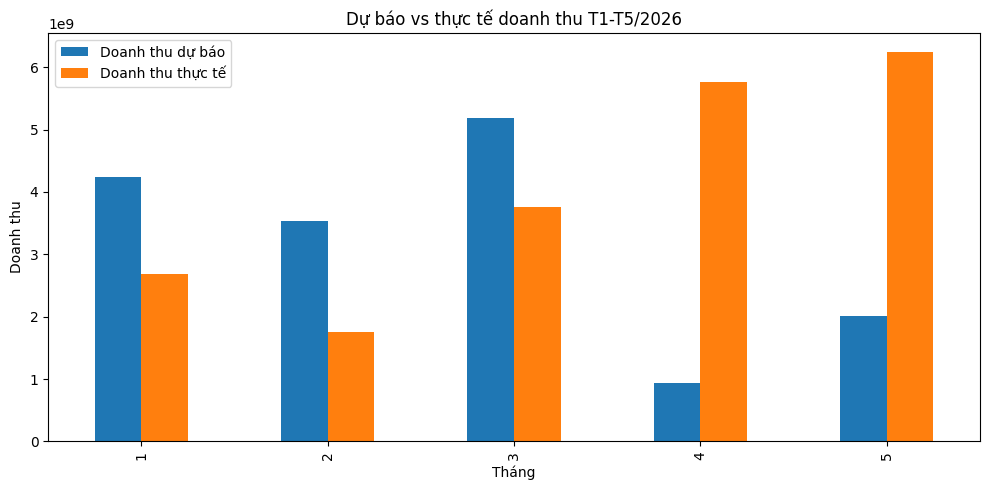

In [4]:
print("Dự báo doanh thu T1-T5/2026")
display(forecast)

print("So sánh dự báo với thực tế 2026")
display(comparison)



comparison.plot(
    x="Tháng",
    y=["Doanh thu dự báo", "Doanh thu thực tế"],
    kind="bar",
    figsize=(10, 5),
    title="Dự báo vs thực tế doanh thu T1-T5/2026"
)
plt.ylabel("Doanh thu")
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

In [5]:
print("Model artifacts đề xuất:", MODEL_DATA_DIR)
print("Mart so sánh dự báo - thực tế đề xuất:", MART_DIR / "forecast_vs_actual.csv")

Model artifacts đề xuất: C:\Users\quang\OneDrive\Desktop\DuAnTotNghiep\data\model
Mart so sánh dự báo - thực tế đề xuất: C:\Users\quang\OneDrive\Desktop\DuAnTotNghiep\data\mart\forecast_vs_actual.csv
